# Deo II - Treniranje i evaluacija modela

## Moduli

In [1]:
import pandas as pd
import ast
from matplotlib import pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, accuracy_score, roc_auc_score, roc_curve
import numpy as np

import torch
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

## Seed-ovi

In [2]:
RANDOM_STATE = 7
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed(RANDOM_STATE)
torch.cuda.manual_seed_all(RANDOM_STATE)

torch.use_deterministic_algorithms(True)

## Pretprocesiranje skupa podataka

In [3]:
data = pd.read_csv('data/protein_data.csv')

In [4]:
data.head()

,accession,sequence,labels
0,P03265,MASREEEQRETTPERGRGAARRPPTMEDVSSPSPSPPPPRAPPKKR...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
1,P49913,MKTQRDGHSLGRWSLVLLLLGLVMPLAIIAQVLSYKEAVLRAIDGI...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -..."
2,P03045,MDAQTRRRERRAEKQAQWKAANPLLVGVSAKPVNRPILSLNRKPKS...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
3,P00004,MGDVEKGKKIFVQKCAQCHTVEKGGKHKTGPNLHGLFGRKTGQAPG...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."
4,P27695,MPKRGKKGAVAEDGDELRTEPEAKKSKTAAKKNDKEAAGEGPALYE...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..."


In [5]:
data.dtypes

accession    str
sequence     str
labels       str
dtype: object

In [6]:
data['labels'] = data['labels'].apply(ast.literal_eval)
#data.dtypes

Obe neuronske mreže koje treniramo će na početku sadržati `Embedding` sloj. Za to nam je potrebna fiksna dužina sekvence, pa analiziramo šta da postavimo za tu dužinu.

In [7]:
print("Max length: ", data['sequence'].str.len().max())
print("Average length: ", data['sequence'].str.len().mean())

Max length:  34350
Average length:  584.8510638297872


Vidimo da su neki stringovi vrlo dugacki, ali većina je zapravo relativno mala.

In [8]:
data['sequence_length'] = data['sequence'].str.len()
print("Number of proteins having length over 5000: ", data[data['sequence_length'] >= 5000].shape[0])
print("Number of proteins having length over 2000: ", data[data['sequence_length'] >= 2000].shape[0])
print("Number of proteins having length over 1000: ", data[data['sequence_length'] >= 1000].shape[0])
print("Number of proteins having length over 500: ", data[data['sequence_length'] >= 500].shape[0])
data[data['sequence_length'] >= 5000]

Number of proteins having length over 5000:  5
Number of proteins having length over 2000:  109
Number of proteins having length over 1000:  434
Number of proteins having length over 500:  1340


,accession,sequence,labels,sequence_length
52,Q8WZ42,MTTQAPTFTQPLQSVVVLEGSTATFEAHISGFPVPEVSWFRDGQVI...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",34350
1124,O14686,MDSQKLAGEDKDSEPAADGPAASEDPSATESDLPNPHVGEVSVLSS...,"[-5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -5, -...",5537
1948,P0C6X7,MESLVLGVNEKTHVQLSLPVLQVRDVLVRGFGDSVEEALSEAREHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, ...",7073
1949,P0DTD1,MESLVPGFNEKTHVQLSLPVLQVRDVLVRGFGDSVEEVLSEARQHL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",7096
3305,P11716,MGDGGEGEDEVQFLRTDDEVVLQCSATVLKEQLKLCLAAEGFGNRL...,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...",5037


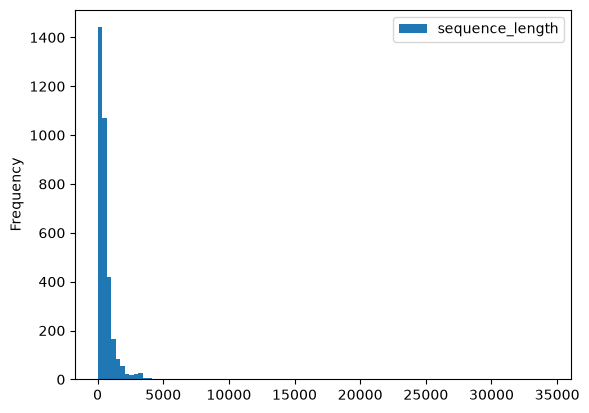

In [9]:
data.plot.hist(bins=100)
plt.show()

Nemamo mnogo proteina dužine veće od $1000$. Nema smisla vršiti padding do maksimalne dužine, pošto će većina instanci imati padding barem $30$ puta duži od njihove prave dužine. Ovaj problem mogli bismo da rešimo izbacivanjem velikih instanci iz skupa podataka, ali mi zaista želimo da smo u mogućnosti da analiziramo i velike proteine. Srećom, struktura naših modela nam omogućava da ovo jednostavno rešimo. Naime, jedan dugačak protein možemo deliti na više manjih, nad kojima model može vršiti predviđanja. Jedini problem koji ovde nastaje je što model gubi na izražajnosti kad su u pitanju dugački proteini, jer se smanjuje kontekst.

In [10]:
MAX_PROTEIN_LENGTH = 1000

RESIDUE_LIST  = list("ACDEFGHIKLMNPQRSTVWY")
VOCAB_SIZE = 22

def get_residue_position(c):
    for j in range(len(RESIDUE_LIST)):
        if c == RESIDUE_LIST[j]:
            # ostavljamo 0 za padding
            return j + 1
    # nestandardne aminokiseline dobijaju zajednicku vrednost
    return len(RESIDUE_LIST) + 1

def tokenize_sequences(sequences):
    result = []
    for sequence in sequences:
        tokenized_seq = []
        for c in sequence:
            tokenized_seq.append(get_residue_position(c.upper()))
        result.append(tokenized_seq)
    return result
    
tokenized_sequences = tokenize_sequences(data['sequence'])
#print(len(tokenized_sequences))
#print(tokenized_sequences[:5])

In [11]:
def split_and_pad(sequence_list, label_list):
    """
    Imamo dva zadatka:
    1) Podeliti predugacke proteine
    2) Pad-ovati prekratke proteine
    """
    
    seq_res = []
    lab_res = []
    
    cnt_new_splits = 0
    
    for i in range(len(sequence_list)):
        sequence = sequence_list[i]
        labels = label_list[i]
        
        # deljenje
        for j in range(len(sequence)):
            l = j*MAX_PROTEIN_LENGTH
            r = j*MAX_PROTEIN_LENGTH + MAX_PROTEIN_LENGTH
            
            if l >= len(sequence):
                break
            
            if j >= 1:
                cnt_new_splits += 1
            
            r = min(r, len(sequence))
            
            seq_split = sequence[l:r]
            lab_split = labels[l:r]
            
            start_len = len(seq_split)
            
            # padding
            for k in range(start_len, MAX_PROTEIN_LENGTH):
                # mozemo kao label dati istu "neutvrdjenu vrednost"
                # svakako to ne racunamo u funkciji greske
                seq_split.append(0)
                lab_split.append(-5)
            
            seq_res.append(seq_split)
            lab_res.append(lab_split)
            
    print("Generated ", cnt_new_splits, " new splits")
    
    return seq_res, lab_res
    
    
seq_train_val, seq_test, labels_train_val, labels_test = train_test_split(tokenized_sequences, data['labels'].tolist(), random_state = RANDOM_STATE, test_size = 0.2)
seq_train, seq_val, labels_train, labels_val = train_test_split(seq_train_val, labels_train_val, random_state = RANDOM_STATE, test_size = 0.2)

seq_train, labels_train = split_and_pad(seq_train, labels_train)
seq_val, labels_val = split_and_pad(seq_val, labels_val)
seq_test, labels_test = split_and_pad(seq_test, labels_test)

seq_train = np.array(seq_train)
labels_train = np.array(labels_train)
seq_val = np.array(seq_val)
labels_val = np.array(labels_val)
seq_test = np.array(seq_test)
labels_test = np.array(labels_test)

Generated  400  new splits
Generated  93  new splits
Generated  146  new splits


In [12]:
BATCH_SIZE = 64

train_loader = DataLoader(list(zip(seq_train, labels_train)), batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(list(zip(seq_val, labels_val)), batch_size=BATCH_SIZE)
test_loader = DataLoader(list(zip(seq_test, labels_test)), batch_size=BATCH_SIZE)

## Funkcije

In [13]:
def calculate_metrics(y_target, y_predicted):
    sensitivity = recall_score(y_target, y_predicted)
    specificity = recall_score(y_target, y_predicted, pos_label = 0)
    accuracy = accuracy_score(y_target, y_predicted)
    
    return {'sensitivity' : sensitivity, 'specificity' : specificity, 'accuracy' : accuracy}

In [14]:
from tqdm import tqdm

def get_device():
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")

def train_model(model, optimizer, n_epochs, train_loader, val_loader, threshold = 0.5):

    metrics = {
        'train_loss': [],
        'train_accuracy': [],
        'train_steps': [],
        'val_loss': [],
        'val_accuracy': [],
        'val_steps': []
    }

    device = get_device()
    
    training_step = 0
    
    best_valid_loss = float('inf')
    eps = 1e-5
    steps_since_improvement = 0
    early_stopping_patience = 10
    
    for epoch in tqdm(range(n_epochs)):

        # Training phase
        model.train()
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)

            batch_size = labels.size(0)
            labels = labels.to(torch.float32)

            raw_predictions = model(inputs).squeeze()
            probs = torch.sigmoid(raw_predictions) 
            
            mask = (labels > -1)
            
            loss = nn.BCEWithLogitsLoss()(raw_predictions[mask], labels[mask].float())
            accuracy = ((probs[mask] > threshold) == labels[mask]).float().mean()

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            metrics['train_loss'].append(loss.item())
            metrics['train_accuracy'].append(accuracy.item())
            metrics['train_steps'].append(training_step)
            training_step += 1

        # Validation phase
        model.eval()
        valid_loss = 0
        valid_accuracy = 0
        valid_samples = 0
        
        y_target = []
        y_predicted = []
        
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)

                batch_size = labels.size(0)
                labels = labels.to(torch.float32)

                raw_predictions = model(inputs).squeeze()
                probs = torch.sigmoid(raw_predictions)
                
                mask = (labels > -1)
            
                loss = nn.BCEWithLogitsLoss(reduction='sum')(raw_predictions[mask], labels[mask])
                
                correct = ((probs[mask] > threshold) == labels[mask]).float().sum()
                
                y_target.extend((labels[mask]).cpu().numpy())
                y_predicted.extend((probs[mask] > threshold).cpu().numpy())
                
                valid_loss += loss.item()
                valid_accuracy += correct.item()
                valid_samples += mask.sum()
                
        valid_loss /= valid_samples.item()
        valid_accuracy /= valid_samples.item()
        
        adv_metrics = calculate_metrics(y_target, y_predicted)
        
        metrics['val_loss'].append(valid_loss)
        metrics['val_accuracy'].append(adv_metrics['accuracy'])
        metrics['val_steps'].append(training_step)
        
        print('Epoch', epoch, ':', 'Loss', valid_loss, 'Accuracy', adv_metrics['accuracy'], 'Sensitivity', adv_metrics['sensitivity'], 'Specificity', adv_metrics['specificity'])
        
        if best_valid_loss > valid_loss + eps:
            best_valid_loss = valid_loss
            steps_since_improvement = 0
        else:
            steps_since_improvement += 1
            if steps_since_improvement == early_stopping_patience:
                print("\nEARLY STOPPING\n")
                break
        
    
    return metrics

In [15]:
def plot_metrics(metrics):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, 1)
    plt.plot(metrics['train_steps'], metrics['train_loss'], label='Train Loss')
    plt.plot(metrics['val_steps'], metrics['val_loss'], label='Validation Loss')
    plt.xlabel('Training Steps')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(metrics['train_steps'], metrics['train_accuracy'], label='Train Accuracy')
    plt.plot(metrics['val_steps'], metrics['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Training Steps')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

## 1D Konvolutivna neuronska mreža

In [16]:
class ConvModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, n_layers):
        super().__init__()
        
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        
        kernel = 5
        channels = 64
        in_channels = embedding_dim
        dropout = 0.3
        
        conv_layers = []
        
        for i in range(n_layers):
            # velika dilatacija kako bismo pokupili sirok kontekst
            dilation = (2 ** i)
            # padding odgovarajuce velicine, kako bismo ocuvali duzinu niza
            pad = dilation * (kernel - 1) // 2
            conv_layers.append(nn.Conv1d(in_channels, channels, kernel_size=kernel, padding = pad, dilation=dilation))
            
            # trebaju nam svi elementi niza, ne mozemo pool-ovati
            conv_layers.append(nn.BatchNorm1d(channels))
            conv_layers.append(nn.ReLU())
            conv_layers.append(nn.Dropout(dropout))
            
            in_channels = channels
            
        self.full_conv = nn.Sequential(*conv_layers)
        
        self.conv_final = nn.Conv1d(channels, 1, 1)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)
        x = self.full_conv(x)
        x = self.conv_final(x)
        
        return x

In [17]:
device = get_device()

conv_model = ConvModel(vocab_size=VOCAB_SIZE, embedding_dim=32, n_layers = 4)
conv_model.to(device)
optimizer = torch.optim.AdamW(conv_model.parameters(), weight_decay = 1e-4, lr = 1e-3)
conv_metrics = train_model(conv_model, optimizer, 50, train_loader, val_loader, threshold=0.5)

  2%|▊                                          | 1/50 [00:01<01:06,  1.36s/it]

Epoch 0 : Loss 0.6307661133080135 Accuracy 0.6779776368918203 Sensitivity 0.3048021689224984 Specificity 0.9708551070820052


  4%|█▋                                         | 2/50 [00:02<00:56,  1.17s/it]

Epoch 1 : Loss 0.5783708222615926 Accuracy 0.7123353369996163 Sensitivity 0.425391351317662 Specificity 0.9375361763530975


  6%|██▌                                        | 3/50 [00:03<00:52,  1.11s/it]

...

Epoch 21 : Loss 0.556158642081217 Accuracy 0.7257550289587634 Sensitivity 0.5426565145581651 Specificity 0.8694553369801815


 46%|███████████████████▎                      | 23/50 [00:24<00:28,  1.04s/it]

Epoch 22 : Loss 0.5576802377207878 Accuracy 0.7239188423802825 Sensitivity 0.5645534907394903 Specificity 0.8489927688055893


 46%|███████████████████▎                      | 23/50 [00:25<00:29,  1.10s/it]

Epoch 23 : Loss 0.5647833279497173 Accuracy 0.7248871795808745 Sensitivity 0.5114418971839325 Specificity 0.8924043925226026

EARLY STOPPING



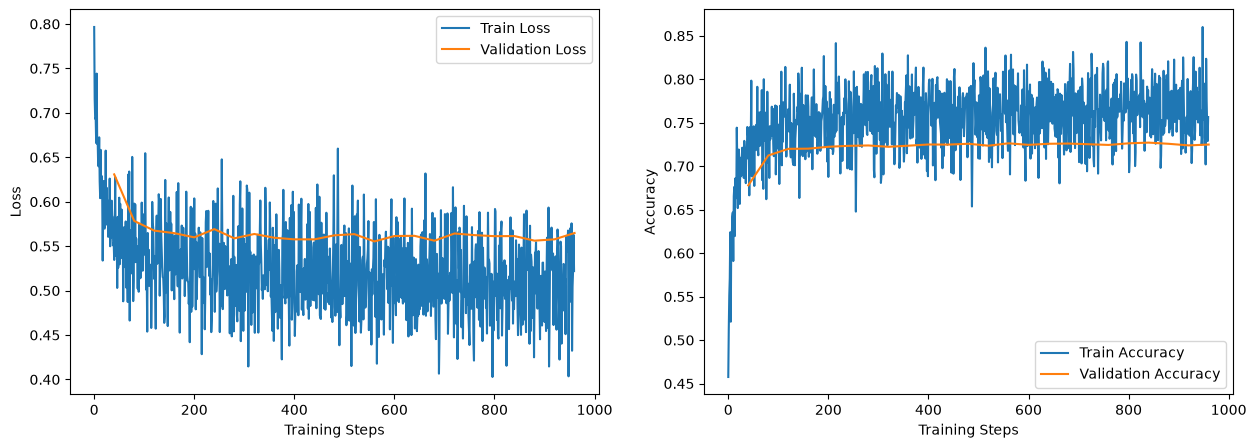

In [18]:
plot_metrics(conv_metrics)

## Rekurentna neuronska mreža - LSTM

In [19]:
class LSTMModel(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        # koristimo dvosmerni LSTM
        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers=1, batch_first=True, bidirectional=True)
        
        self.linear = nn.Linear(2*hidden_size, 1)
    
    def forward(self, x):
        x = self.embedding(x)
        x, _ = self.lstm(x)

        x = self.linear(x)
        return x

In [20]:
device = get_device()

lstm_model = LSTMModel(vocab_size=VOCAB_SIZE, embedding_dim=32, hidden_size=64)
lstm_model.to(device)
optimizer = torch.optim.AdamW(lstm_model.parameters(), weight_decay = 1e-4, lr = 1e-3)
lstm_metrics = train_model(lstm_model, optimizer, 50, train_loader, val_loader, threshold=0.5)

  2%|▊                                          | 1/50 [00:01<00:59,  1.21s/it]

Epoch 0 : Loss 0.6122163815063011 Accuracy 0.6845869950486909 Sensitivity 0.5331622848476665 Specificity 0.803428906842324


  4%|█▋                                         | 2/50 [00:02<00:57,  1.20s/it]

Epoch 1 : Loss 0.5724840727157862 Accuracy 0.7049403467743409 Sensitivity 0.602426533982902 Specificity 0.7853957591123648


  6%|██▌                                        | 3/50 [00:03<00:56,  1.19s/it]

...

Epoch 24 : Loss 0.5534496548871339 Accuracy 0.727070505910511 Sensitivity 0.5633900840353593 Specificity 0.8555310077203395


 52%|█████████████████████▊                    | 26/50 [00:30<00:28,  1.18s/it]

Epoch 25 : Loss 0.5580726612244327 Accuracy 0.7285275793397037 Sensitivity 0.5429681413539146 Specificity 0.8741592819350579


 52%|█████████████████████▊                    | 26/50 [00:31<00:29,  1.23s/it]

Epoch 26 : Loss 0.5607898023487315 Accuracy 0.7207032320537884 Sensitivity 0.5859207013680416 Specificity 0.826483943813538

EARLY STOPPING



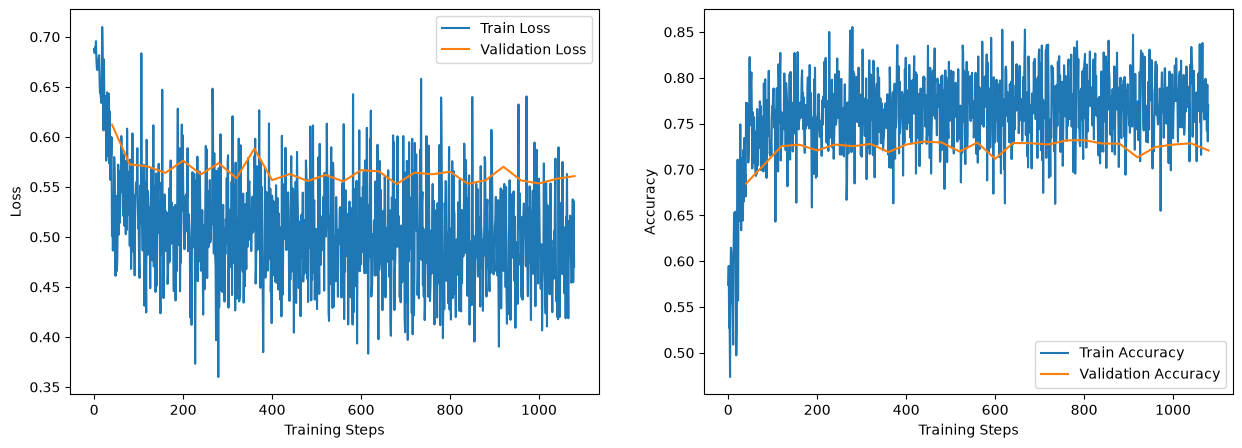

In [21]:
plot_metrics(lstm_metrics)

# Evaluacija

In [22]:
from sklearn.metrics import confusion_matrix, classification_report

def evaluate_model(model, evaluation_loader, threshold):
    y = []
    y_predicted = []
    y_probs = []
    
    device = get_device()
    
    for inputs, labels in evaluation_loader:
        mask = (labels > -1)
        
        y.extend(labels[mask].squeeze().tolist())
        
        inputs, labels = inputs.to(device), labels.to(device)
        
        raw_preds = model(inputs).squeeze()
        probs = torch.sigmoid(raw_preds)
        preds = (probs > threshold)
        
        y_probs.extend(probs[mask].squeeze().tolist())
        y_predicted.extend(preds[mask].squeeze().tolist())

    conf = confusion_matrix(y, y_predicted)
    print(conf)
    print(classification_report(y, y_predicted))
    adv_metrics = calculate_metrics(y, y_predicted)
    adv_metrics['probs'] = y_probs
    adv_metrics['labels'] = y
    
    print('Sensitivity:', adv_metrics['sensitivity'])
    print('Specificity:', adv_metrics['specificity'])
    print('Accuracy:', adv_metrics['accuracy'])
    print('ROC AUC score:', roc_auc_score(y, y_probs))
    
    return adv_metrics

In [23]:
conv_stats = evaluate_model(conv_model, test_loader, threshold = 0.5)

[[137111  22797]
 [ 51673  68554]]
              precision    recall  f1-score   support

           0       0.73      0.86      0.79    159908
           1       0.75      0.57      0.65    120227

    accuracy                           0.73    280135
   macro avg       0.74      0.71      0.72    280135
weighted avg       0.74      0.73      0.73    280135

Sensitivity: 0.5702046961165129
Specificity: 0.8574367761462841
Accuracy: 0.7341638852696022
ROC AUC score: 0.758411200157267


In [24]:
lstm_stats = evaluate_model(lstm_model, test_loader, threshold = 0.5)

[[127055  32853]
 [ 42409  77818]]
              precision    recall  f1-score   support

           0       0.75      0.79      0.77    159908
           1       0.70      0.65      0.67    120227

    accuracy                           0.73    280135
   macro avg       0.73      0.72      0.72    280135
weighted avg       0.73      0.73      0.73    280135

Sensitivity: 0.6472589351809493
Specificity: 0.7945506166045476
Accuracy: 0.7313366769593231
ROC AUC score: 0.7656845525816109


In [25]:
existing_models = pd.DataFrame([
    ("DisEMBL-465", 0.4191, 0.9503, 0.7414),
    ("DisEMBL-hl", 0.5301, 0.7206, 0.6456),
    ("ESpritzD", 0.4197, 0.9574, 0.7459),
    ("ESpritzN", 0.6862, 0.8081, 0.7966),
    ("ESpritzX", 0.5714, 0.9553, 0.8043),
    ("FoldIndex", 0.6223, 0.7593, 0.7061),
    ("GlobPlot", 0.4073, 0.9100, 0.6952),
    ("IUPredL", 0.6442, 0.9167, 0.8056),
    ("IUPredS", 0.5496, 0.9409, 0.7870),
    ("JRONN", 0.7258, 0.8125, 0.7789),
    ("VSL2b", 0.8067, 0.7750, 0.7875),
], columns=["Model", "Sensitivity", "Specificity", "Accuracy"])

existing_models

,Model,Sensitivity,Specificity,Accuracy
0,DisEMBL-465,0.4191,0.9503,0.7414
1,DisEMBL-hl,0.5301,0.7206,0.6456
2,ESpritzD,0.4197,0.9574,0.7459
3,ESpritzN,0.6862,0.8081,0.7966
4,ESpritzX,0.5714,0.9553,0.8043
5,FoldIndex,0.6223,0.7593,0.7061
6,GlobPlot,0.4073,0.9100,0.6952
7,IUPredL,0.6442,0.9167,0.8056
8,IUPredS,0.5496,0.9409,0.7870
9,JRONN,0.7258,0.8125,0.7789


In [26]:
project_models = pd.DataFrame([
    ("1D Conv. Model", conv_stats['sensitivity'], conv_stats['specificity'], conv_stats['accuracy']),
    ("LSTM Model", lstm_stats['sensitivity'], lstm_stats['specificity'], lstm_stats['accuracy'])
], columns=["Model", "Sensitivity", "Specificity", "Accuracy"])

project_models

,Model,Sensitivity,Specificity,Accuracy
0,1D Conv. Model,0.570205,0.857437,0.734164
1,LSTM Model,0.647259,0.794551,0.731337


In [27]:
def plot_roc_curve(model_stat_list, existing_models):
    plt.figure(figsize=(10,10))
    
    for model_stats in model_stat_list:
        fpr, tpr, _ = roc_curve(model_stats['labels'], model_stats['probs'])
        auc = roc_auc_score(model_stats['labels'], model_stats['probs'])
        
        plt.plot(fpr, tpr, label = model_stats['name'])
    
    plt.plot([0, 1], [0, 1], ls="--", color="black")
    
    
    xs = 1 - existing_models["Specificity"].values
    ys = existing_models["Sensitivity"].values
    plt.scatter(xs, ys, color='darkred', label="Individual predictors (paper)")

    
    for _, row in existing_models.iterrows():
        plt.annotate(row["Model"], (1 - row["Specificity"], row["Sensitivity"]), \
                    textcoords="offset points", xytext=(6, -2))

    
    
    plt.grid(True, alpha=0.5)
    
    plt.xlabel('False positive rate')
    plt.ylabel('True positive rate')
    plt.legend()
    plt.tight_layout()
    
    plt.savefig('images/roc_curve.png', dpi=300, bbox_inches='tight')
    
    plt.show()

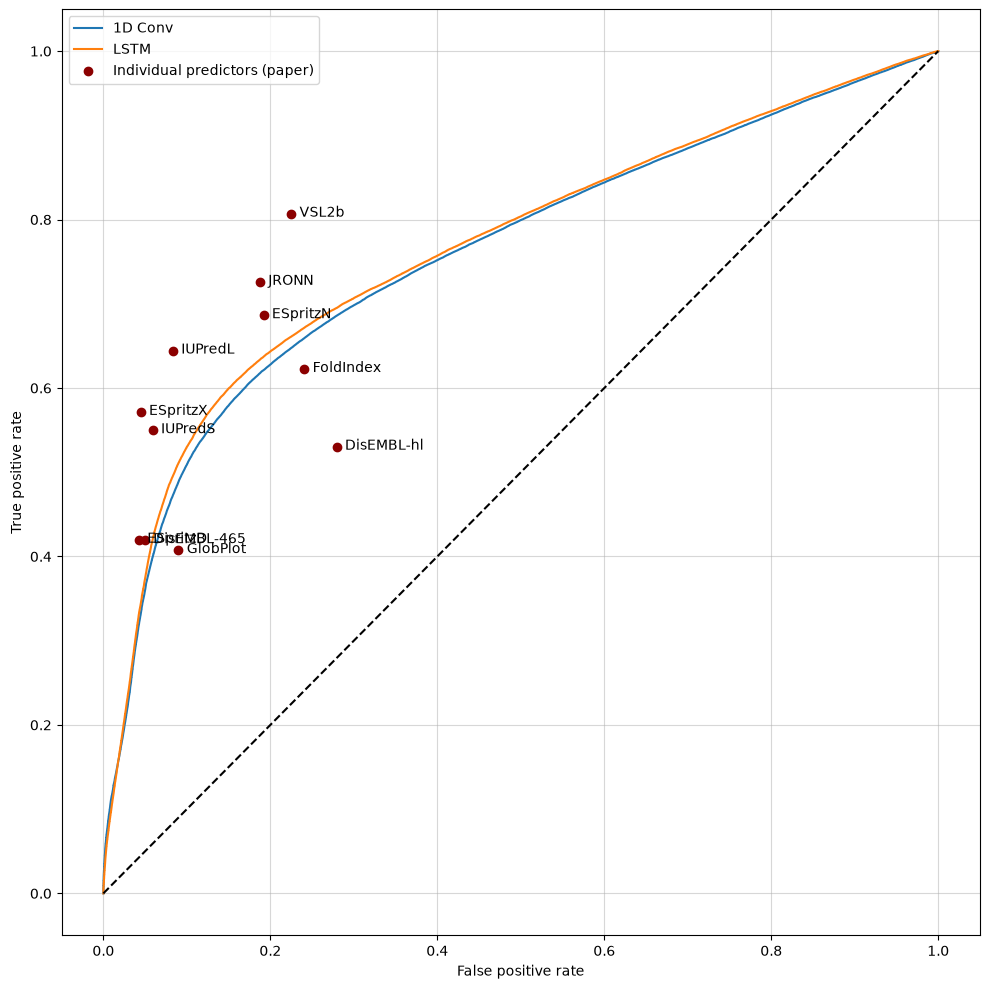

In [28]:
conv_stats['name'] = "1D Conv"
lstm_stats['name'] = "LSTM"

plot_roc_curve([conv_stats, lstm_stats], existing_models)

Vidimo da su oba modela gotovo ista.

## Čuvanje istreniranih modela

In [29]:
torch.save(conv_model.state_dict(), "saved_models/conv_model.pt")

In [30]:
torch.save(lstm_model.state_dict(), "saved_models/lstm_model.pt")

## Vizualizacija na primeru

/tmp/ipykernel_43964/2586018085.py:8: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  x = torch.tensor([seq])


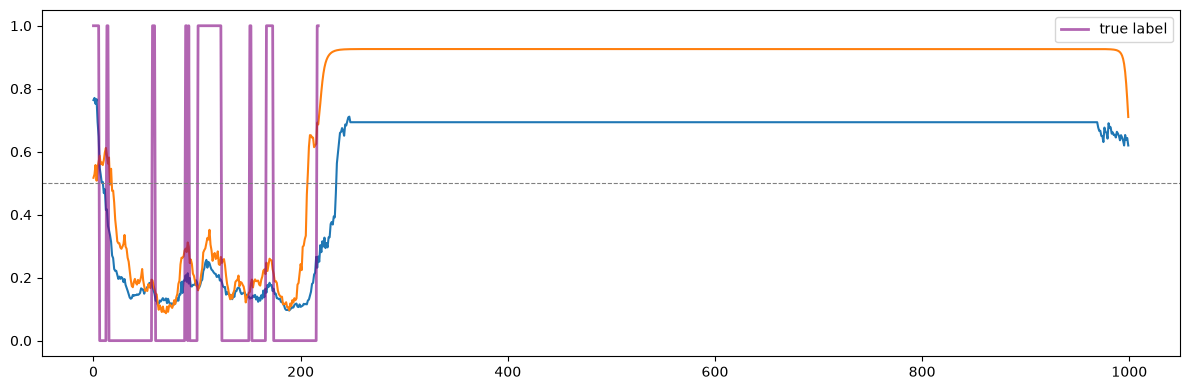

In [31]:
def plot_protein_predictions(models, seq, labels):
    
    plt.figure(figsize=(12, 4))
    
    for model in models:
        model.eval()
        with torch.no_grad():
            x = torch.tensor([seq])
            x = x.to(get_device())
            probs = torch.sigmoid(model(x)).cpu().numpy().squeeze()

            plt.plot(probs)
            
    truth = np.array([v if v > -1 else np.nan for v in labels])
    
    plt.plot(truth, label="true label", linewidth=2, alpha=0.6, color="purple")
    plt.axhline(0.5, ls="--", c="gray", lw=0.8)

    plt.legend()
    plt.tight_layout()
    plt.show()

    
idx = np.random.randint(0, len(seq_test))
sample_test_protein_seq = seq_test[idx]
sample_test_protein_labels = labels_test[idx]
plot_protein_predictions([conv_model, lstm_model], sample_test_protein_seq, sample_test_protein_labels)

Vizualizacijom raznih primera može se doći do zaključka da su naši modeli previše rigidni, tj. da ne reaguju dovoljno brzo na uređene/neuređene oblasti male dužine. To se u konvolutivnoj neuronskoj mreži može rešiti npr. smanjenjem dilatacije, mada rezulati na LSTM pokazuju da je gledanje širokog konteksta zaista tačniji izbor. Dakle, iako ne reaguju na male oblasti, modeli imaju sposobnost da ostaju konzistentni na velikoj, pa time zaista predviđaju velike povezane oblasti, a ne samo nasumične niske nula i jedinica.